# 07 - Análise Temporal: CNEFE 2010 × Censo 2022 (BA)

Compara o perfil de cada setor censitário entre os dois momentos.

**CNEFE 2010** não tem COD_ESPECIE, mas tem:
- `total_enderecos` por setor (proxy de densidade)
- `situacao` 1=urbano, 2=rural/localidade (proxy de urbanidade)

**O que podemos mapear:**
- Crescimento/declínio de endereços por setor
- Setores novos em 2022 (expansão urbana)
- Setores que mudaram de perfil rural → urbano
- Correlação entre crescimento e tipo de cluster em 2022

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

con = duckdb.connect()
CNEFE_2010 = "'../data/cnefe_2010/*.snappy.parquet'"
OUTPUT_DIR = Path('../outputs')

In [2]:
# Perfil 2010 por setor (filtrando BA)
df_2010 = con.execute(f"""
    SELECT
        setor                                                      AS cod_setor,
        COUNT(*)                                                   AS total_2010,
        SUM(CASE WHEN situacao = '1' THEN 1 ELSE 0 END) * 1.0
            / COUNT(*)                                             AS prop_urbano_2010,
        SUM(CASE WHEN situacao = '2' THEN 1 ELSE 0 END) * 1.0
            / COUNT(*)                                             AS prop_rural_2010
    FROM read_parquet({CNEFE_2010})
    WHERE uf = '29'
    GROUP BY setor
""").df()

print(f'Setores BA em 2010: {len(df_2010):,}')
df_2010.head()

Setores BA em 2010: 23,903


,cod_setor,total_2010,prop_urbano_2010,prop_rural_2010
0,293330705000179,210,1.0,0.0
1,293330705000183,266,1.0,0.0
2,293330705000199,334,1.0,0.0
3,293330705000230,334,0.0,1.0
4,293330705000231,328,0.0,1.0


In [3]:
# Carrega perfil 2022 com clusters já atribuídos
df_2022 = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')
df_2022 = df_2022.rename(columns={
    'COD_SETOR': 'cod_setor',
    'total_enderecos': 'total_2022'
})

print(f'Setores BA em 2022: {len(df_2022):,}')
df_2022[['cod_setor', 'total_2022', 'lat_centroide', 'lon_centroide', 'cluster', 'cluster_nome']].head()

Setores BA em 2022: 30,355


,cod_setor,total_2022,lat_centroide,lon_centroide,cluster,cluster_nome
0,291840705000165P,195,-9.421509,-40.501849,12,Setor Urbano Típico
1,291840705000088P,350,-9.427444,-40.506557,12,Setor Urbano Típico
2,290100705000014P,792,-13.027812,-39.609417,12,Setor Urbano Típico
3,290560205000044P,376,-15.424717,-39.495352,12,Setor Urbano Típico
4,291080005110174P,254,-12.287674,-38.931778,12,Setor Urbano Típico


In [4]:
# Join: setores presentes nos dois anos
# Códigos 2022 têm sufixo 'P' (ex: 291840705000165P) — remove para casar com 2010
df_2022['cod_setor'] = df_2022['cod_setor'].str[:-1]

df = df_2022[['cod_setor', 'total_2022', 'lat_centroide', 'lon_centroide',
              'cluster', 'cluster_nome']].merge(
    df_2010[['cod_setor', 'total_2010', 'prop_urbano_2010', 'prop_rural_2010']],
    on='cod_setor', how='left'
)

novos_2022   = df['total_2010'].isna().sum()
em_ambos     = df['total_2010'].notna().sum()
apenas_2010  = len(df_2010) - em_ambos

print(f'Setores presentes nos dois anos : {em_ambos:,}')
print(f'Setores novos em 2022           : {novos_2022:,}  (expansão urbana)')
print(f'Setores apenas em 2010          : {apenas_2010:,}  (extintos ou reclassificados)')

Setores presentes nos dois anos : 19,371
Setores novos em 2022           : 10,984  (expansão urbana)
Setores apenas em 2010          : 4,532  (extintos ou reclassificados)


In [5]:
# Métricas de mudança para setores em ambos os anos
df_match = df[df['total_2010'].notna()].copy()

df_match['delta_abs']  = df_match['total_2022'] - df_match['total_2010']
df_match['taxa_cresc'] = (df_match['total_2022'] - df_match['total_2010']) / df_match['total_2010']

print(df_match[['total_2010', 'total_2022', 'delta_abs', 'taxa_cresc']].describe().round(2))

       total_2010  total_2022  delta_abs  taxa_cresc
count    19371.00    19371.00   19371.00    19371.00
mean       251.99      314.56      62.57        0.39
std        127.19      161.42     113.05        1.70
min          1.00        5.00   -1668.00       -0.99
25%        166.00      205.00      11.00        0.06
50%        246.00      300.00      46.00        0.21
75%        326.00      406.00     102.00        0.46
max       2143.00     2269.00    2123.00       89.00


In [6]:
# Classificação da trajetória de cada setor
def classificar_trajetoria(row):
    if row['prop_rural_2010'] > 0.5 and row['taxa_cresc'] > 0.3:
        return 'Rural → Urbano'
    if row['prop_urbano_2010'] > 0.8 and row['taxa_cresc'] > 0.3:
        return 'Adensamento Urbano'
    if row['taxa_cresc'] < -0.2:
        return 'Declínio'
    if abs(row['taxa_cresc']) <= 0.2:
        return 'Estável'
    return 'Crescimento Moderado'

df_match['trajetoria'] = df_match.apply(classificar_trajetoria, axis=1)

# Setores novos em 2022
df_novos = df[df['total_2010'].isna()].copy()
df_novos['trajetoria'] = 'Novo Setor (2022)'
df_novos['delta_abs']  = np.nan
df_novos['taxa_cresc'] = np.nan

df_tempo = pd.concat([df_match, df_novos], ignore_index=True)

print('Distribuição de trajetórias:')
print(df_tempo['trajetoria'].value_counts())

Distribuição de trajetórias:
trajetoria
Novo Setor (2022)       10984
Estável                  8118
Rural → Urbano           3883
Adensamento Urbano       3487
Crescimento Moderado     2533
Declínio                 1350
Name: count, dtype: int64


/tmp/ipykernel_1488697/705389702.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


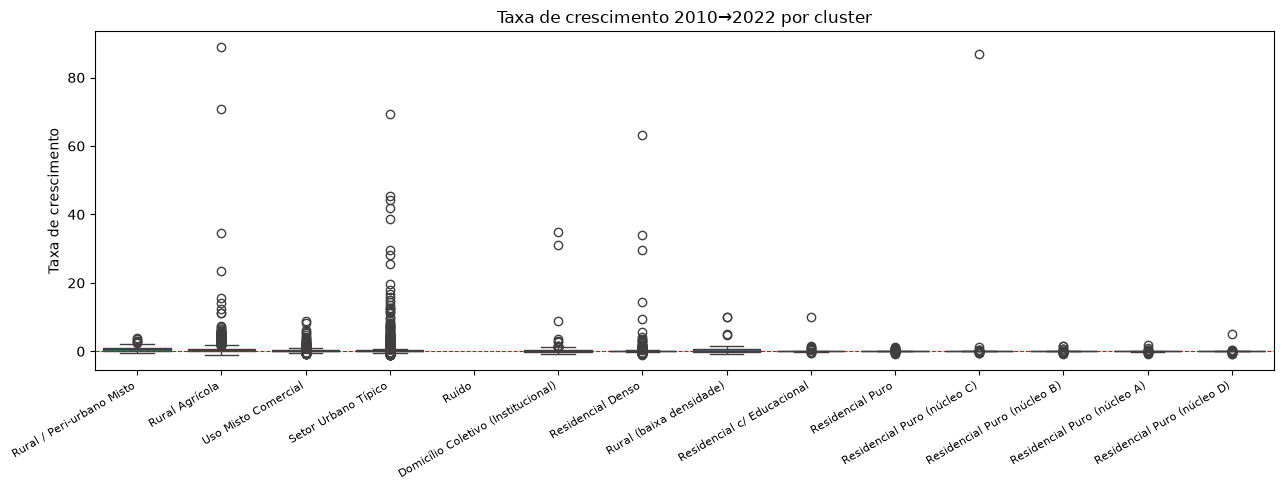

In [7]:
# Distribuição da taxa de crescimento por cluster de 2022
fig, ax = plt.subplots(figsize=(13, 5))
ordem = df_match.groupby('cluster_nome')['taxa_cresc'].median().sort_values(ascending=False).index
sns.boxplot(data=df_match[df_match['cluster_nome'] != 'Ruído'],
            x='cluster_nome', y='taxa_cresc', order=ordem, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_title('Taxa de crescimento 2010→2022 por cluster')
ax.set_xlabel('')
ax.set_ylabel('Taxa de crescimento')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/crescimento_por_cluster_ba.png', dpi=150)
plt.show()

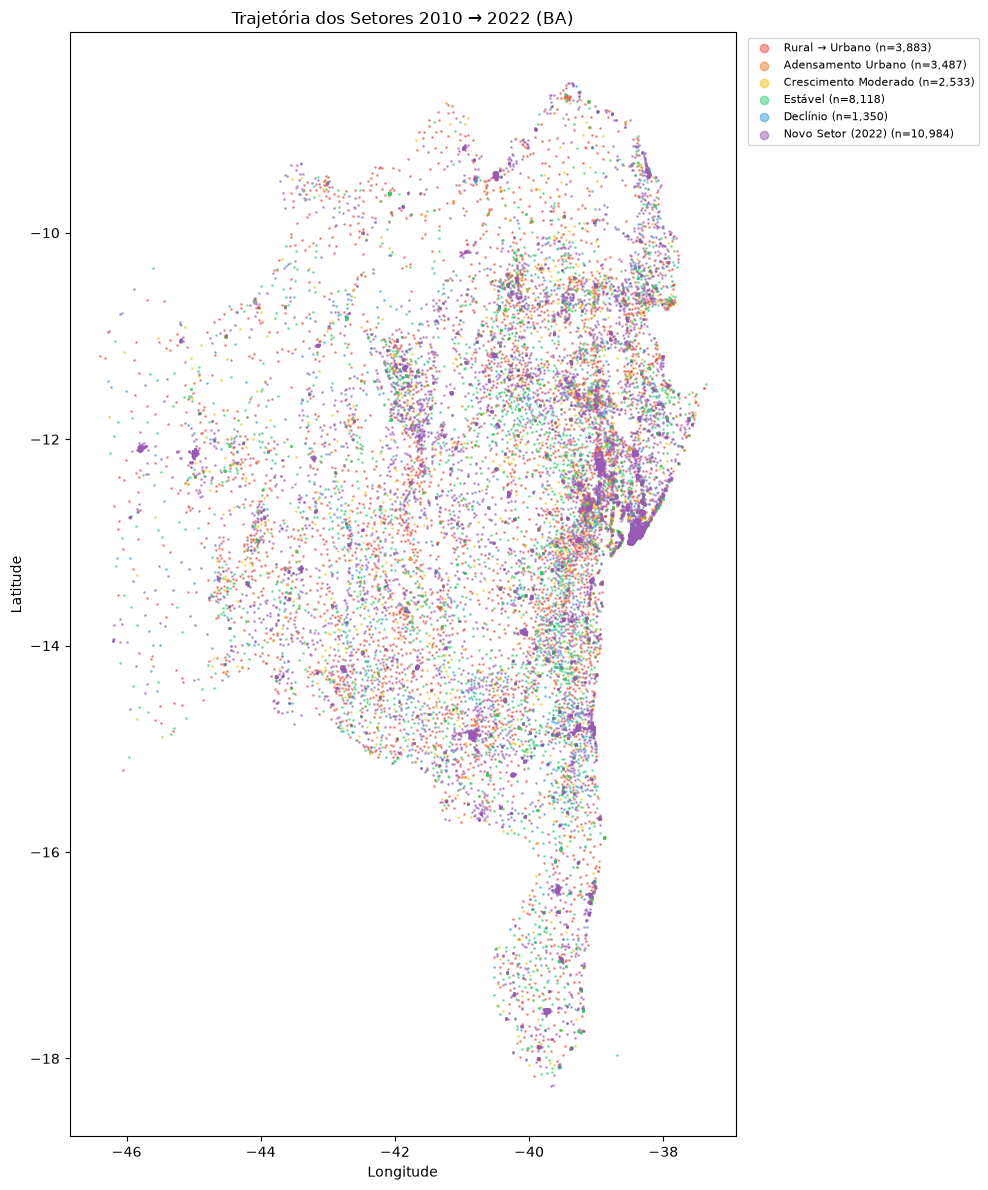

In [8]:
# Mapa: trajetória de cada setor
palette_traj = {
    'Rural → Urbano'     : '#e74c3c',
    'Adensamento Urbano' : '#e67e22',
    'Crescimento Moderado': '#f1c40f',
    'Estável'            : '#2ecc71',
    'Declínio'           : '#3498db',
    'Novo Setor (2022)'  : '#9b59b6',
}

fig, ax = plt.subplots(figsize=(10, 12))
for traj, cor in palette_traj.items():
    sub = df_tempo[df_tempo['trajetoria'] == traj]
    if len(sub):
        ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
                   s=1, alpha=0.5, color=cor, label=f'{traj} (n={len(sub):,})')

ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title('Trajetória dos Setores 2010 → 2022 (BA)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/mapa_trajetoria_temporal_ba.png', dpi=150)
plt.show()

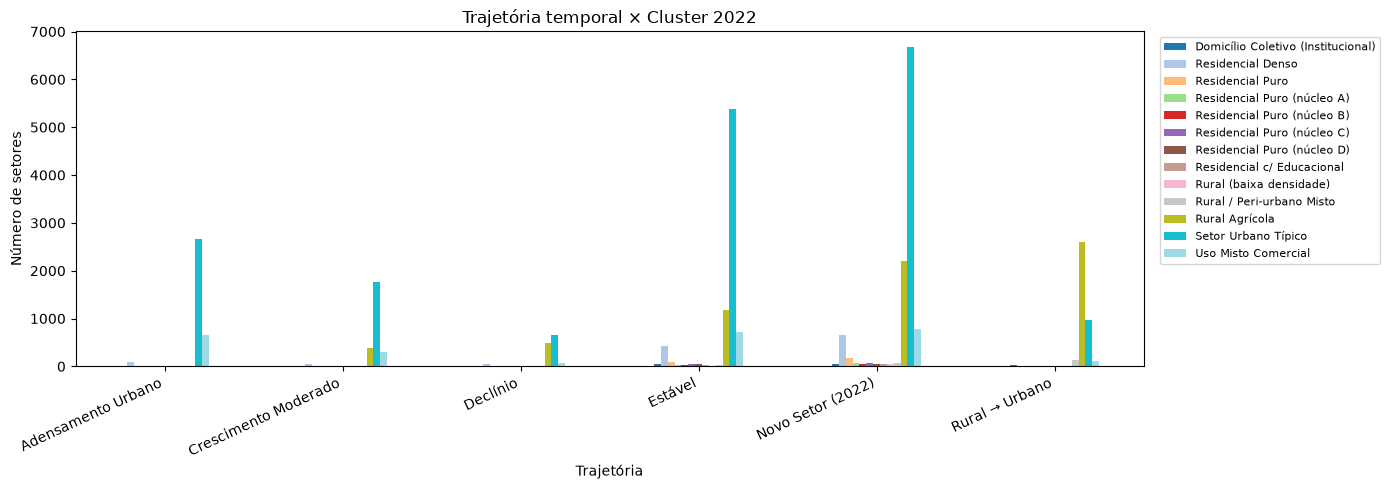

In [9]:
# Cruzamento: trajetória × cluster 2022
pivot = (df_tempo[df_tempo['cluster_nome'] != 'Ruído']
         .groupby(['trajetoria', 'cluster_nome'])
         .size()
         .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 5))
pivot.plot(kind='bar', ax=ax, colormap='tab20')
ax.set_title('Trajetória temporal × Cluster 2022')
ax.set_xlabel('Trajetória')
ax.set_ylabel('Número de setores')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/trajetoria_vs_cluster_ba.png', dpi=150)
plt.show()

In [10]:
# Salvar
df_tempo.to_parquet(OUTPUT_DIR / 'analise_temporal_ba.parquet', index=False)
print('Salvo: outputs/analise_temporal_ba.parquet')

Salvo: outputs/analise_temporal_ba.parquet
